In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# Step 1: Load data
data = pd.read_csv("../data/raw/raw.csv", low_memory=False)

# Step 2: Keep all needed columns
cols = ["CC22_302", "CC22_412", "pid3", 
        "HouseCand1Party", "HouseCand2Party", "HouseCand3Party",
        "HouseCand4Party", "HouseCand5Party", "HouseCand6Party",
        "HouseCand7Party", "HouseCand8Party"]

df = data[cols].dropna(subset=["CC22_302", "CC22_412", "pid3"])


# Step 3: Filter valid econ_perception values (1-5 only, drop 6 = Not sure)
df = df[df["CC22_302"].isin([1, 2, 3, 4, 5])]

# Step 4: Filter valid CC22_412 values (1-8 only, drop 10,11,12,13)
df = df[df["CC22_412"].isin([1, 2, 3, 4, 5, 6, 7, 8])]

# Step 5: Map vote to Democrat (1) or not (0)
def map_voted_dem(row):
    vote = row["CC22_412"]
    party_col = f"HouseCand{int(vote)}Party"
    party = row[party_col]
    if party == "Democratic":
        return 1
    elif pd.notna(party):
        return 0
    return np.nan

df["voted_dem_house"] = df.apply(map_voted_dem, axis=1)

# Step 6: Drop rows where mapping failed
df = df.dropna(subset=["voted_dem_house"])

# Step 7: Map party_id integers to labels
df["party_id"] = df["pid3"].map({
    1: "Democrat",
    2: "Republican",
    3: "Independent",
    4: "Other",
    5: "Not sure"
})

# Step 8: Drop ambiguous party categories
df = df[df["party_id"].isin(["Democrat", "Republican", "Independent"])]

# Step 9: Rename and keep only needed columns
df = df.rename(columns={"CC22_302": "econ_perception"})
df = df[["econ_perception", "voted_dem_house", "party_id"]]

df.to_csv("../data/processed/cleaned_data.csv", index=False)

# Step 10: Sanity checks
print("Shape:", df.shape)
print("\nVote distribution:")
print(df["voted_dem_house"].value_counts())
print("\nParty distribution:")
print(df["party_id"].value_counts())
print("\nEcon perception distribution (should be 1-5 only):")
print(df["econ_perception"].value_counts().sort_index())
print("\nSample:")
df.head(20)

Shape: (35628, 3)

Vote distribution:
voted_dem_house
1.0    20025
0.0    15603
Name: count, dtype: int64

Party distribution:
party_id
Democrat       15445
Republican     10645
Independent     9538
Name: count, dtype: int64

Econ perception distribution (should be 1-5 only):
econ_perception
1.0     1273
2.0     4556
3.0     4266
4.0     9852
5.0    15681
Name: count, dtype: int64

Sample:


,econ_perception,voted_dem_house,party_id
0,2.0,1.0,Democrat
1,5.0,0.0,Independent
2,4.0,1.0,Democrat
5,5.0,0.0,Independent
7,2.0,1.0,Democrat
8,4.0,1.0,Democrat
9,2.0,1.0,Democrat
12,4.0,1.0,Independent
13,5.0,0.0,Independent
14,4.0,1.0,Democrat


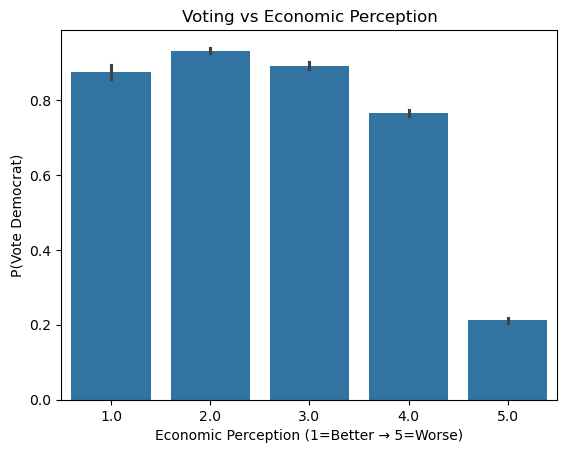

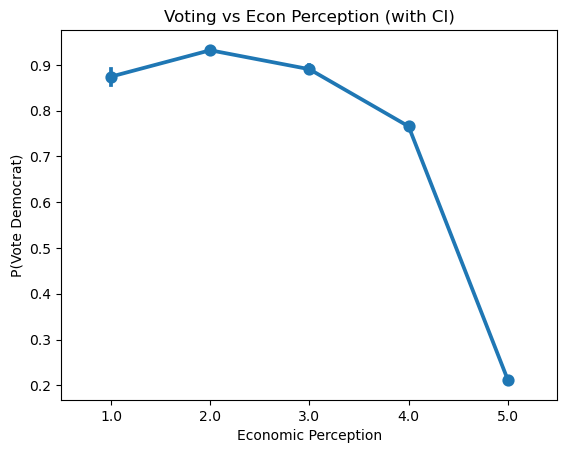

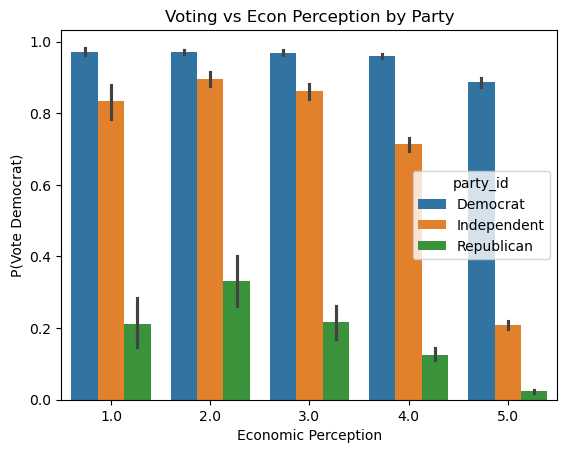

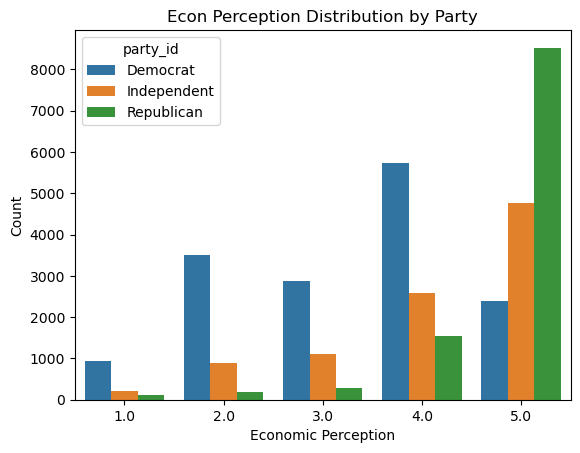

In [4]:
# ---------- Plot 1: Overall relationship ----------
plt.figure()
sns.barplot(data=df, x="econ_perception", y="voted_dem_house")
plt.ylabel("P(Vote Democrat)")
plt.xlabel("Economic Perception (1=Better → 5=Worse)")
plt.title("Voting vs Economic Perception")
plt.savefig("../reports/figures/econ_vs_vote.png", dpi=300, bbox_inches="tight")
plt.show()

# ---------- Plot 2: With confidence intervals ----------
plt.figure()
sns.pointplot(data=df, x="econ_perception", y="voted_dem_house", errorbar="ci")
plt.ylabel("P(Vote Democrat)")
plt.xlabel("Economic Perception")
plt.title("Voting vs Econ Perception (with CI)")
plt.savefig("../reports/figures/econ_vs_vote_ci.png", dpi=300, bbox_inches="tight")
plt.show()

# ---------- Plot 3: By party ----------
plt.figure()
sns.barplot(data=df, x="econ_perception", y="voted_dem_house", hue="party_id")
plt.ylabel("P(Vote Democrat)")
plt.xlabel("Economic Perception")
plt.title("Voting vs Econ Perception by Party")
plt.savefig("../reports/figures/econ_vs_vote_by_party.png", dpi=300, bbox_inches="tight")
plt.show()

# ---------- Plot 4: Distribution ----------
plt.figure()
sns.countplot(data=df, x="econ_perception", hue="party_id")
plt.xlabel("Economic Perception")
plt.ylabel("Count")
plt.title("Econ Perception Distribution by Party")
plt.savefig("../reports/figures/econ_distribution_by_party.png", dpi=300, bbox_inches="tight")
plt.show()